In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import resample, butter, filtfilt, find_peaks, iirnotch
from scipy.interpolate import CubicSpline

df = pd.read_csv(r"C:\Users\Adyty\Documents\Farid ITS\TriaGo\draft_filter\data_primer\data3.csv", sep=',', header=0)
df.head()

,Time (s),ECG_Raw (V),ECG_Filtered (V)
0,0.000000,1.596774,0.218295
1,0.003906,2.051613,0.317968
2,0.007812,1.141935,0.345249
3,0.011719,0.674194,0.323113
4,0.015625,0.806452,0.331914


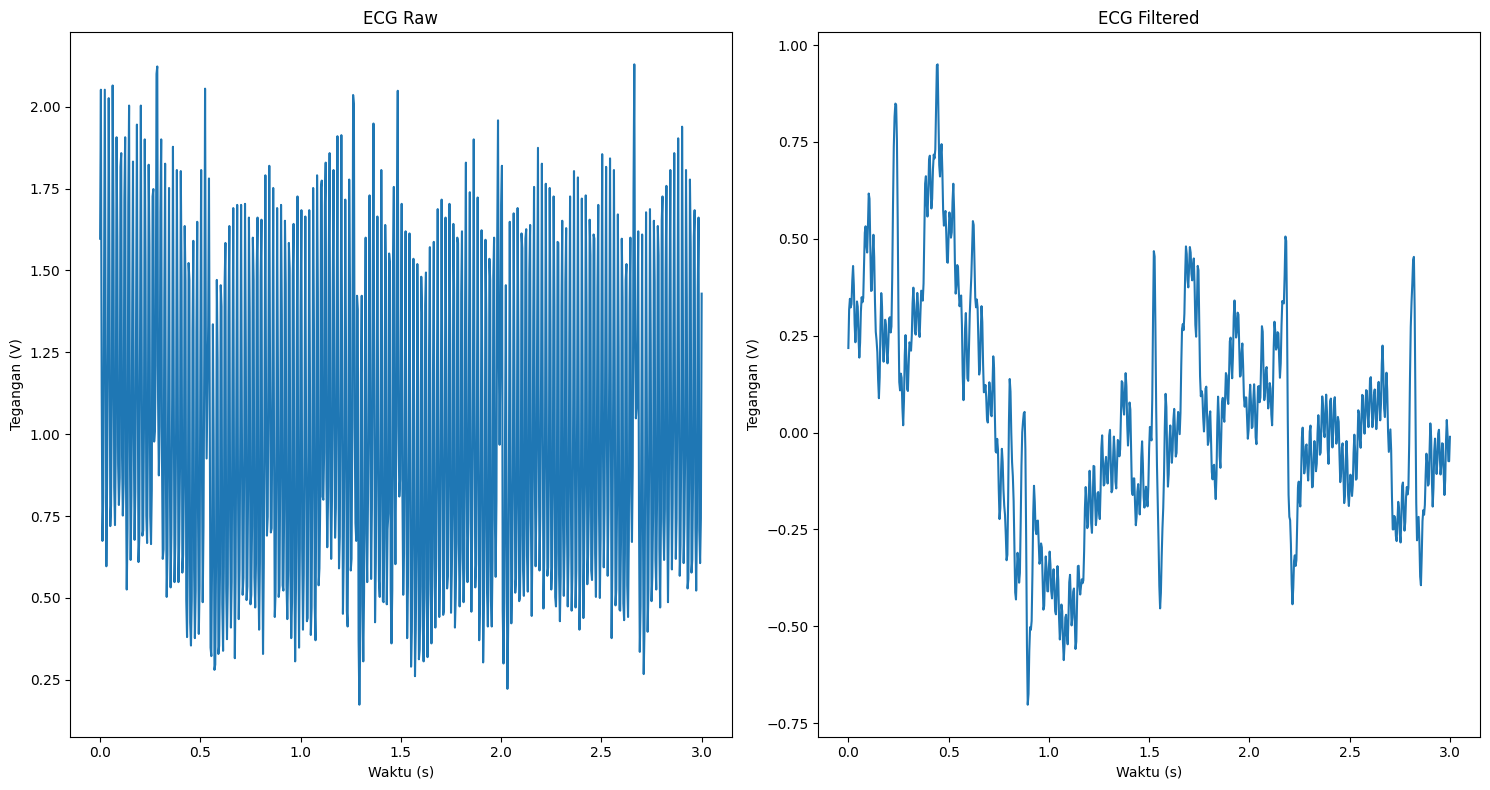

In [4]:
ecg_raw = df['ECG_Raw (V)'].copy()
ecg_filtered = df['ECG_Filtered (V)'].copy()
time = df['Time (s)'].copy()
durasi_real = time <= 3

fig, ax = plt.subplots(1,2, figsize=(15,8))
ax = ax.flatten()

ax[0].plot(time[durasi_real], ecg_raw[durasi_real])
ax[0].set_title('ECG Raw')
ax[0].set_xlabel('Waktu (s)')
ax[0].set_ylabel('Tegangan (V)')

ax[1].plot(time[durasi_real], ecg_filtered[durasi_real])
ax[1].set_title('ECG Filtered')
ax[1].set_xlabel('Waktu (s)')
ax[1].set_ylabel('Tegangan (V)')

plt.tight_layout()
plt.show()

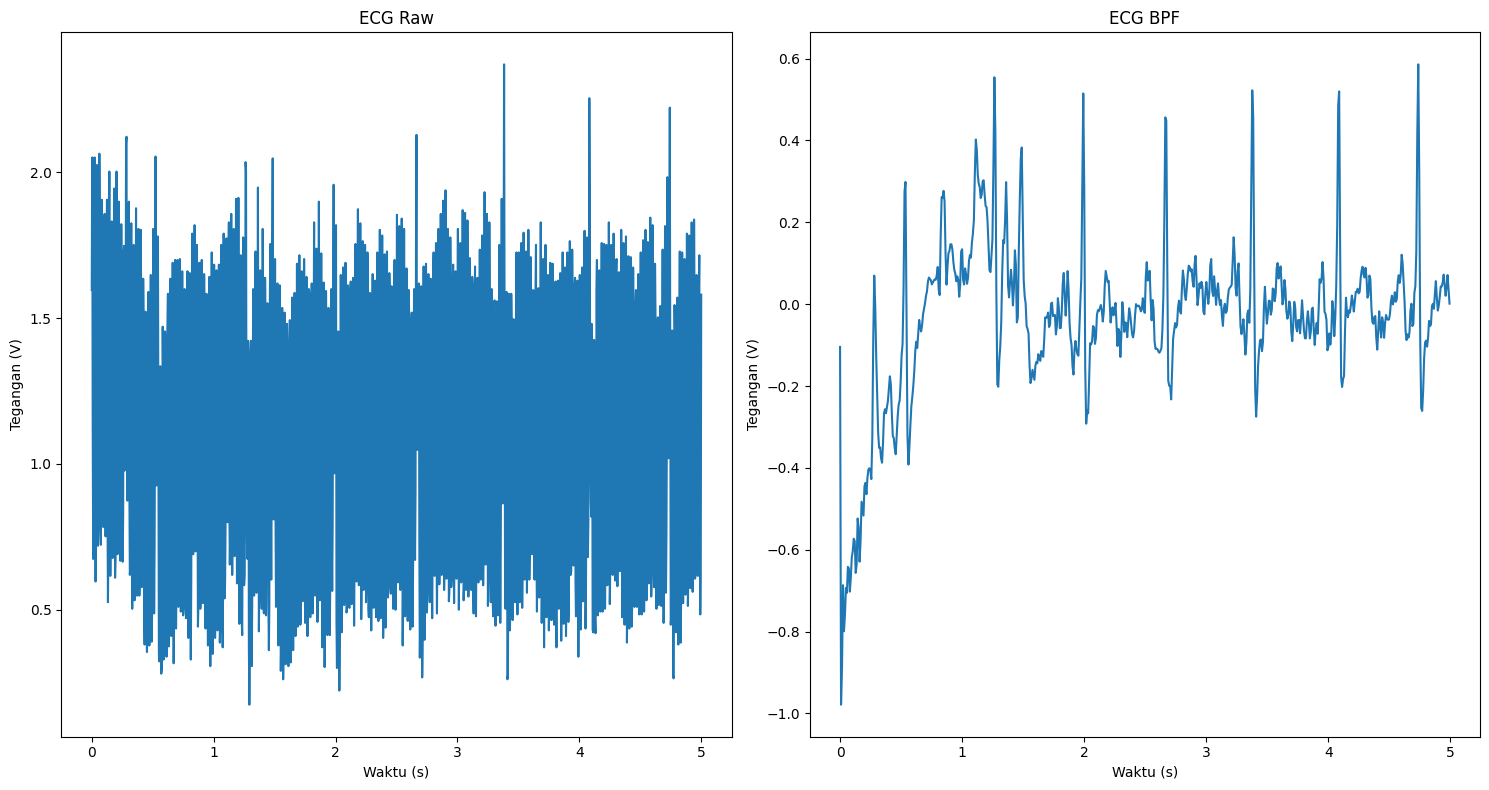

In [5]:
# init
fs = 256 
target_fs = 125

# resample
num_samples = int(len(df)*target_fs/fs)
ecg_resample = resample(ecg_raw, num_samples)
time_resample = np.linspace(time.iloc[0], time.iloc[-1], num_samples)
durasi_resample = time_resample <= 5
durasi = time <= 5

# baseline correction
def bpf(ecg, low_cut=0.5, high_cut=40.0, fs=125, order=4):
    nyq = 0.5 * fs
    low = low_cut / nyq
    high = high_cut / nyq
    
    # Membuat koefisien bandpass
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, ecg)

ecg_bpf = bpf(ecg_resample)

fig, ax = plt.subplots(1,2,figsize=(15,8))
ax[0].plot(time[durasi], ecg_raw[durasi])
ax[0].set_title('ECG Raw')
ax[0].set_xlabel('Waktu (s)')
ax[0].set_ylabel('Tegangan (V)')

ax[1].plot(time_resample[durasi_resample], ecg_bpf[durasi_resample])
ax[1].set_title('ECG BPF')
ax[1].set_xlabel('Waktu (s)')
ax[1].set_ylabel('Tegangan (V)')

plt.tight_layout()
plt.show()


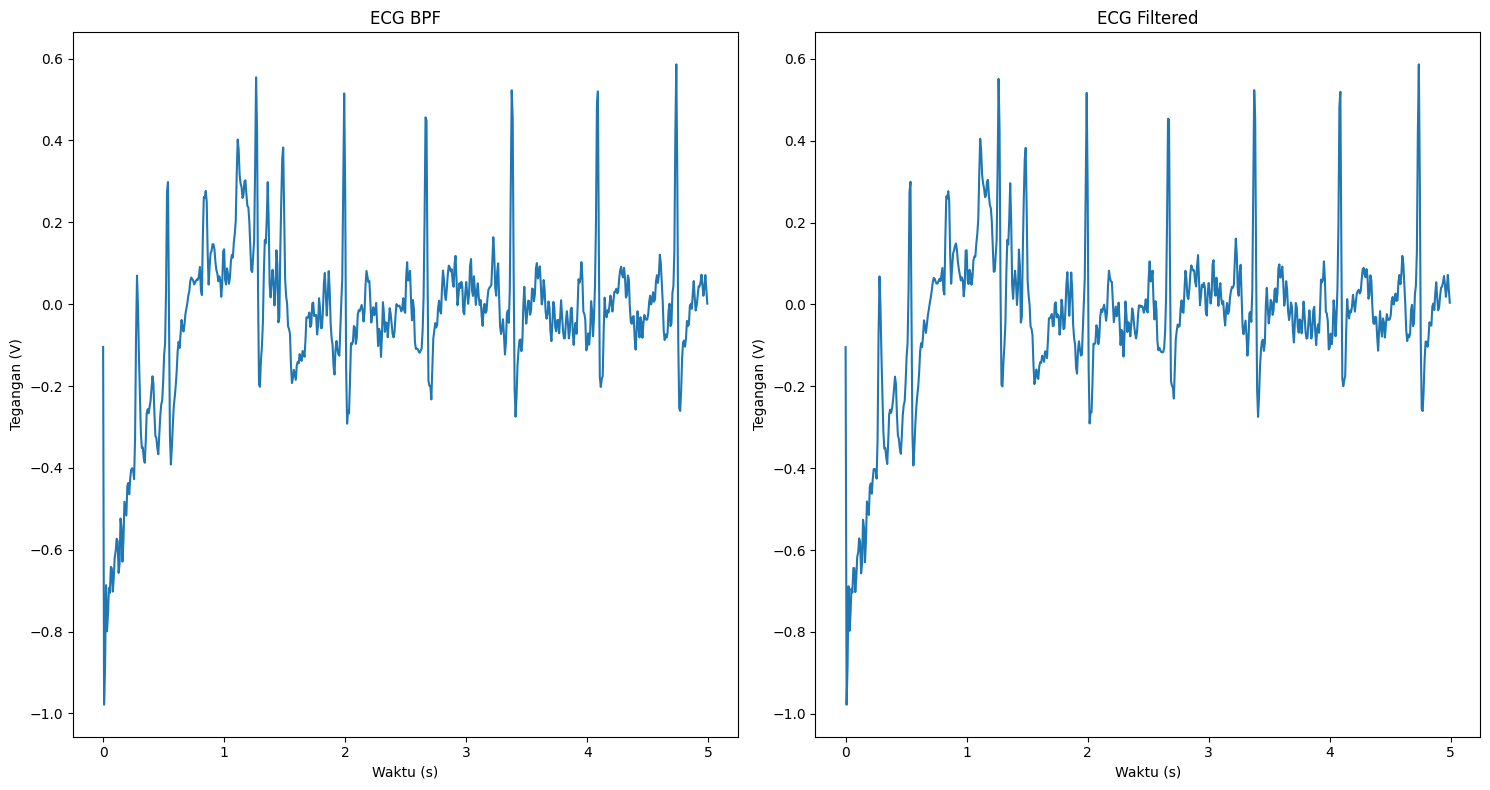

In [6]:
def notch(ecg, freq=50.0, fs=125, Q=30.0):
    nyq = 0.5 * fs
    if freq >= nyq:
        print(f"Warning: Frekuensi notch ({freq} Hz) melampaui batas Nyquist ({nyq} Hz). Filter notch diabaikan.")
        return ecg
        
    b, a = iirnotch(freq, Q, fs)
    return filtfilt(b, a, ecg)

ecg_notch = notch(ecg_bpf)

fig, ax = plt.subplots(1,2,figsize=(15,8))
ax[0].plot(time_resample[durasi_resample], ecg_bpf[durasi_resample])
ax[0].set_title('ECG BPF')
ax[0].set_xlabel('Waktu (s)')
ax[0].set_ylabel('Tegangan (V)')

ax[1].plot(time_resample[durasi_resample], ecg_notch[durasi_resample])
ax[1].set_title('ECG Filtered')
ax[1].set_xlabel('Waktu (s)')
ax[1].set_ylabel('Tegangan (V)')

plt.tight_layout()
plt.show()

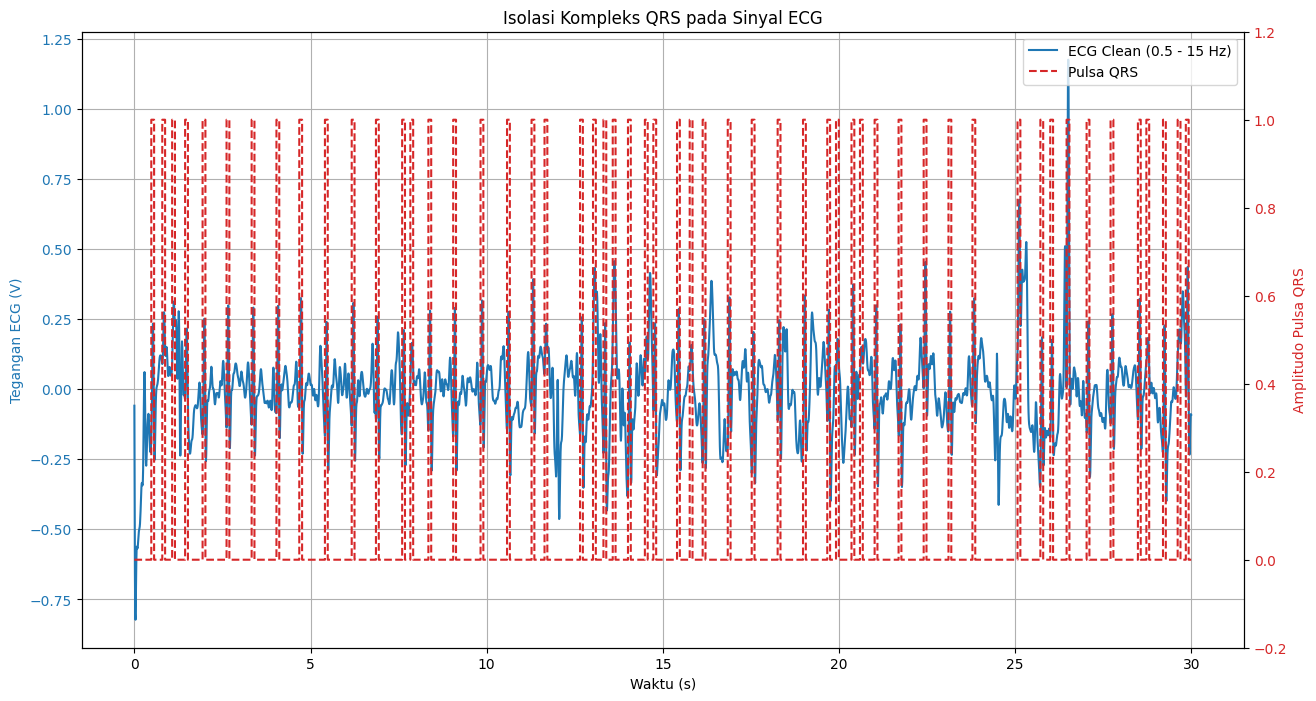

<Figure size 640x480 with 0 Axes>

In [7]:
def isolate_qrs(ecg, fs=125):
    nyq = 0.5 * fs
    
    # 1. Bandpass filter (0.5 - 15 Hz) untuk mempermudah isolasi QRS
    low = 0.5 / nyq
    high = 15.0 / nyq
    b, a = butter(4, [low, high], btype='band')
    ecg_clean = filtfilt(b, a, ecg)
    
    n_samples = len(ecg)
    qrs_pulses = np.zeros(n_samples)
    
    # Jeda dinamis disesuaikan untuk HR ~100 BPM
    samples_200ms = int(0.22 * fs)  # Diperketat sedikit ke 220ms untuk memblokir T-wave dekat
    samples_360ms = int(0.36 * fs)
    win_width = int(0.04 * fs)      # Lebar pulsa dipersempit ke ±40 ms agar lebih presisi
    
    # Hitung gradien absolut sinyal (QRS memiliki slope jauh lebih tinggi dari T-wave)
    slope = np.abs(np.diff(ecg_clean))
    slope = np.append(slope, 0)
    
    # Threshold adaptif dinaikkan menjadi 0.8 std deviasi untuk mengeliminasi T-wave tinggi
    mean_ecg = np.mean(ecg_clean)
    std_ecg = np.std(ecg_clean)
    initial_threshold = mean_ecg + (0.9 * std_ecg)
    
    # Ekstraksi kandidat puncak lokal awal
    candidate_peaks = []
    for i in range(1, n_samples - 1):
        if ecg_clean[i] > initial_threshold:
            if ecg_clean[i] > ecg_clean[i - 1] and ecg_clean[i] > ecg_clean[i + 1]:
                candidate_peaks.append(i)
                
    if len(candidate_peaks) == 0:
        return qrs_pulses, ecg_clean
        
    # Proses seleksi puncak R murni
    valid_qrs_peaks = [candidate_peaks[0]]
    r_slopes = [slope[candidate_peaks[0]]]
    
    for current_peak in candidate_peaks[1:]:
        last_valid = valid_qrs_peaks[-1]
        time_diff = current_peak - last_valid
        
        # Aturan 1: Jika berada di dalam zona refractory T-wave (220 ms)
        if time_diff < samples_200ms:
            # Bandingkan kemiringan (slope) dan amplitudo, QRS asli pasti memenangkan keduanya
            if slope[current_peak] > slope[last_valid] and ecg_clean[current_peak] > ecg_clean[last_valid]:
                valid_qrs_peaks[-1] = current_peak
                r_slopes[-1] = slope[current_peak]
            continue
            
        # Aturan 2: Check back error untuk puncak yang tertinggal jauh
        if time_diff > samples_360ms:
            missed_peaks = [p for p in candidate_peaks if last_valid < p < current_peak]
            avg_r_slope = np.mean(r_slopes[-5:])
            
            for mp in missed_peaks:
                # Menaikkan batas kemiringan ke 0.85 agar benar-benar hanya QRS yang lolos, bukan T-wave
                if (mp - valid_qrs_peaks[-1] >= samples_200ms) and (slope[mp] >= 0.85 * avg_r_slope):
                    valid_qrs_peaks.append(mp)
                    r_slopes.append(slope[mp])
                    
        # Tambahkan puncak jika jarak aman dari puncak terakhir terpenuhi
        if current_peak - valid_qrs_peaks[-1] >= samples_200ms:
            valid_qrs_peaks.append(current_peak)
            r_slopes.append(slope[current_peak])
            
    # Pembentukan pulsa kotak akhir
    for peak in valid_qrs_peaks:
        start_idx = max(0, peak - win_width)
        end_idx = min(n_samples, peak + win_width)
        qrs_pulses[start_idx:end_idx] = 1.0
        
    return qrs_pulses, ecg_clean

# Eksekusi fungsi isolasi QRS
qrs_signal, ecg_clean = isolate_qrs(ecg_notch, fs=target_fs)
durasi_resample = time_resample <= 30
fig, ax1 = plt.figure(figsize=(15, 8)), plt.gca()

# Plot Sinyal ECG Bersih (Sumbu Y Sebelah Kiri)
color = 'tab:blue'
ax1.set_xlabel('Waktu (s)')
ax1.set_ylabel('Tegangan ECG (V)', color=color)
ax1.plot(time_resample[durasi_resample], ecg_clean[durasi_resample], color=color, label='ECG Clean (0.5 - 15 Hz)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

# Plot Pulsa Isolasi QRS (Sumbu Y Sebelah Kanan)
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Amplitudo Pulsa QRS', color=color)
ax2.plot(time_resample[durasi_resample], qrs_signal[durasi_resample], color=color, drawstyle='steps-pre', linestyle='--', label='Pulsa QRS')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(-0.2, 1.2)

# Menggabungkan Legenda dari Kedua Sumbu
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Isolasi Kompleks QRS pada Sinyal ECG')
plt.show()

plt.tight_layout()
plt.show()

Heart Rate: 102.24051828856797 bpm


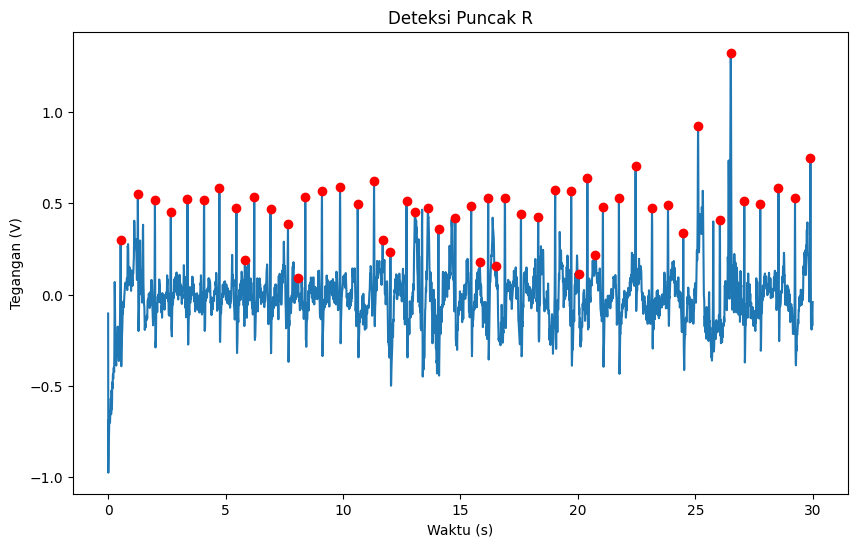

In [ ]:
# ekstraksi fitur denyut jantung
def hr(ecg, fs=125, window_size=0.5):
    """
    Algoritma kustom deteksi puncak R dengan performa setara scipy.signal.find_peaks.
    Menggunakan moving threshold berbasis statistik sinyal dan pembersihan jarak minimum.
    """
    n_samples = len(ecg)
    
    # 1. Menentukan parameter tinggi minimal berbasis standar deviasi (seperti Scipy)
    mean_ecg = np.mean(ecg)
    std_ecg = np.std(ecg)
    min_height = mean_ecg + (0.5 * std_ecg)
    
    # 2. Menentukan jarak minimum antar puncak (0.3 detik untuk menghindari T-wave/noise)
    min_distance_samples = int(0.3 * fs)
    
    # 3. Fase Pertama: Cari semua titik maksimum lokal yang melebihi min_height
    # Jendela geser lokal sekecil 3 sampel untuk memastikan titik tersebut adalah 'puncak tajam'
    candidate_peaks = []
    for i in range(1, n_samples - 1):
        if ecg[i] > min_height:
            # Cek apakah titik i lebih tinggi dari tetangga langsung kiri dan kanannya
            if ecg[i] > ecg[i - 1] and ecg[i] > ecg[i + 1]:
                candidate_peaks.append(i)
                
    # 4. Fase Kedua: Terapkan pemfilteran jarak (Refractory Period)
    # Ini meniru parameter `distance` pada Scipy untuk mengeliminasi multi-peak pada satu QRS
    r_peaks = []
    if len(candidate_peaks) > 0:
        # Masukkan puncak pertama yang lolos seleksi
        r_peaks.append(candidate_peaks[0])
        
        for p in candidate_peaks[1:]:
            # Cek apakah jarak dari puncak terakhir yang valid sudah memenuhi batas minimum
            if p - r_peaks[-1] >= min_distance_samples:
                r_peaks.append(p)
            else:
                # Jika jaraknya terlalu dekat, pilih yang memiliki amplitudo lebih tinggi
                if ecg[p] > ecg[r_peaks[-1]]:
                    r_peaks[-1] = p  # Ganti dengan puncak yang lebih tinggi
                    
    # 5. Menghitung Heart Rate (BPM)
    if len(r_peaks) > 1:
        rr_intervals_samples = np.diff(r_peaks)
        rr_intervals_seconds = rr_intervals_samples / fs
        mean_rr_interval = np.mean(rr_intervals_seconds)
        bpm = 60.0 / mean_rr_interval
    else:
        bpm = 0.0
        print("Puncak R tidak cukup terdeteksi untuk menghitung HR.")
        
    return bpm, r_peaks


bpm, r_peaks = hr(ecg_notch)
print("Heart Rate:", bpm, "bpm")

plt.figure(figsize=(10, 6))
plt.title('Deteksi Puncak R')
plt.plot(time_resample[durasi_resample], ecg_notch[durasi_resample])

indices_in_duration = np.where(durasi_resample)[0]
r_peaks_in_duration = [p for p in r_peaks if p in indices_in_duration]
plt.plot(time_resample[r_peaks_in_duration], ecg_notch[r_peaks_in_duration], 'ro')

plt.xlabel('Waktu (s)')
plt.ylabel('Tegangan (V)')
plt.show()


Laju Pernapasan: 20.0 BPM


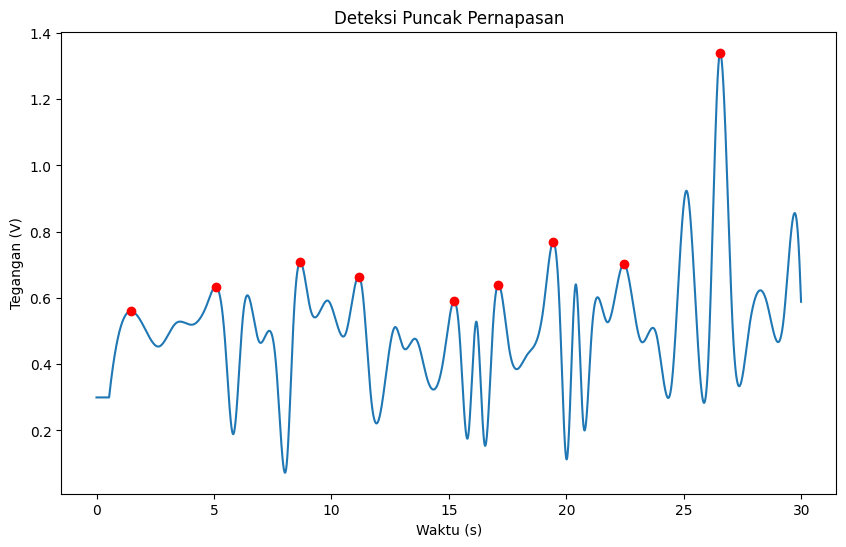

In [9]:
def rr(ecg, r_peaks, fs=125):
    n_samples = len(ecg)
    total_seconds = n_samples / fs
    
    if len(r_peaks) < 4:
        print("Puncak R tidak cukup untuk membentuk sinyal pernapasan.")
        return 0.0, np.zeros(n_samples), np.array([])

    r_amplitudes = ecg[r_peaks]
    cs = CubicSpline(r_peaks, r_amplitudes, extrapolate=False)
    full_indices = np.arange(r_peaks[0], r_peaks[-1])
    resp_signal = cs(full_indices)
    
    resp_signal_full = np.zeros(n_samples)
    resp_signal_full[r_peaks[0]:r_peaks[-1]] = resp_signal
    resp_signal_full[:r_peaks[0]] = resp_signal[0]
    resp_signal_full[r_peaks[-1]:] = resp_signal[-1]

    min_distance_resp = int(1.5 * fs) 
    
    mean_resp = np.mean(resp_signal_full)
    std_resp = np.std(resp_signal_full)
    min_height = mean_resp + (0.1 * std_resp)
    
    candidate_peaks = []
    for i in range(1, n_samples - 1):
        if resp_signal_full[i] > min_height:
            if resp_signal_full[i] > resp_signal_full[i - 1] and resp_signal_full[i] > resp_signal_full[i + 1]:
                candidate_peaks.append(i)
                
    resp_peaks = []
    if len(candidate_peaks) > 0:
        resp_peaks.append(candidate_peaks[0])
        for p in candidate_peaks[1:]:
            if p - resp_peaks[-1] >= min_distance_resp:
                resp_peaks.append(p)
            else:
                if resp_signal_full[p] > resp_signal_full[resp_peaks[-1]]:
                    resp_peaks[-1] = p
                    
    resp_peaks = np.array(resp_peaks)
    b = len(resp_peaks)
    s = total_seconds
    
    if b > 0:
        resp_rate = b / (s / 60.0)
    else:
        resp_rate = 0.0
        
    return resp_rate, resp_signal_full, resp_peaks


rr_rate, rr_signal, rr_peaks = rr(ecg_notch, r_peaks)
print("Laju Pernapasan:", rr_rate, "BPM")
durasi_resample = time_resample <= 30

plt.figure(figsize=(10, 6))
plt.title('Deteksi Puncak Pernapasan')
plt.plot(time_resample[durasi_resample], rr_signal[durasi_resample])

indices_in_duration = np.where(durasi_resample)[0]
rr_peaks_in_duration = [p for p in rr_peaks if p in indices_in_duration]
plt.plot(time_resample[rr_peaks_in_duration], rr_signal[rr_peaks_in_duration], 'ro')

plt.xlabel('Waktu (s)')
plt.ylabel('Tegangan (V)')
plt.show()


In [10]:
def hr_rr(ecg_notch, fs=125, window_size=0.5):
    """
    Menghitung Heart Rate (HR) dan Respiration Rate (RR) berdasarkan alur pemrosesan paper:
    1. Menggunakan modul isolasi QRS untuk mendapatkan pulsa kompleks QRS.
    2. Menghitung HR menggunakan rumus berbasis jumlah detak per durasi detik.
    3. Membentuk sinyal pernapasan melalui interpolasi spline pada amplitudo puncak R.
    4. Menghitung RR menggunakan rumus berbasis jumlah puncak pernapasan per durasi detik.
    """
    n_samples = len(ecg_notch)
    total_seconds = n_samples / fs
    
    # 1. Isolasi Kompleks QRS (menggunakan fungsi yang sudah Anda buat sebelumnya)
    qrs_signal, ecg_clean = isolate_qrs(ecg_notch, fs=fs)
    
    # 2. Ekstraksi lokasi puncak R dari pulsa QRS
    r_peaks = []
    in_pulse = False
    pulse_start = 0
    
    for i in range(n_samples):
        if qrs_signal[i] == 1.0 and not in_pulse:
            in_pulse = True
            pulse_start = i
        elif qrs_signal[i] == 0.0 and in_pulse:
            in_pulse = False
            pulse_end = i
            # Mencari titik maksimum lokal pada ecg_clean di dalam rentang pulsa kotak QRS
            local_max = pulse_start + np.argmax(ecg_clean[pulse_start:pulse_end])
            r_peaks.append(local_max)
            
    r_peaks = np.array(r_peaks)
    
    # ==========================================================
    # 4. PERHITUNGAN HEART RATE (HR)
    # ==========================================================
    # HR (BePM) = h / (m / 60)
    # h = jumlah detak jantung (puncak R), m = durasi total dalam detik
    h = len(r_peaks)
    m = total_seconds
    
    if h > 0:
        bpm = h / (m / 60.0)
    else:
        bpm = 0.0
        
    # ==========================================================
    # 5. PEMBENTUKAN POLA PERNAPASAN (INTERPOLASI SPLINE)
    # ==========================================================
    if len(r_peaks) < 4:
        return bpm, 0.0, r_peaks, np.zeros(n_samples), np.array([])
        
    # Ambil nilai amplitudo pada setiap posisi puncak R dari ecg_clean
    r_amplitudes = ecg_clean[r_peaks]
    
    # Menerapkan penyesuaian kurva interpolasi spline (Cubic Spline)
    cs = CubicSpline(r_peaks, r_amplitudes, extrapolate=False)
    
    full_indices = np.arange(r_peaks[0], r_peaks[-1])
    resp_signal = cs(full_indices)
    
    # Rekonstruksi sinyal pernapasan penuh sepanjang sinyal ECG asli
    resp_signal_full = np.zeros(n_samples)
    resp_signal_full[r_peaks[0]:r_peaks[-1]] = resp_signal
    resp_signal_full[:r_peaks[0]] = resp_signal[0]
    resp_signal_full[r_peaks[-1]:] = resp_signal[-1]
    
    # ==========================================================
    # 6. PERHITUNGAN RESPIRATION RATE (RR)
    # ==========================================================
    # Menentukan jarak minimal logis antar-napas dewasa normal (~1.6 detik) 
    # dan ambang batas tinggi adaptif (menggunakan rata-rata sinyal pernapasan)
    min_distance_resp = int(2 * fs)
    mean_resp = np.mean(resp_signal_full)
    
    candidate_resp_peaks = []
    for i in range(1, n_samples - 1):
        if resp_signal_full[i] > mean_resp:
            # Pengecekan puncak lokal (local maximum)
            if resp_signal_full[i] > resp_signal_full[i - 1] and resp_signal_full[i] > resp_signal_full[i + 1]:
                candidate_resp_peaks.append(i)
                
    # Eliminasi puncak yang terlalu dekat (refractory period)
    resp_peaks = []
    if len(candidate_resp_peaks) > 0:
        resp_peaks.append(candidate_resp_peaks[0])
        for p in candidate_resp_peaks[1:]:
            if p - resp_peaks[-1] >= min_distance_resp:
                resp_peaks.append(p)
            else:
                if resp_signal_full[p] > resp_signal_full[resp_peaks[-1]]:
                    resp_peaks[-1] = p
                    
    resp_peaks = np.array(resp_peaks)
    
    # RR (BPM) = b / (s / 60)
    # b = jumlah pernapasan (puncak kurva), s = durasi total dalam detik
    b = len(resp_peaks)
    s = total_seconds
    
    if b > 0:
        resp_rate = b / (s / 60.0)
    else:
        resp_rate = 0.0
        
    return bpm, resp_rate, r_peaks, resp_signal_full, resp_peaks
    
bpm_hr, resp_rate, r_peaks, resp_signal, resp_peaks = hr_rr(ecg_notch, fs=target_fs)
print(f"Heart Rate: {bpm_hr:.2f} BPM")
print(f"Respiratory Rate: {resp_rate:.2f} BPM")

Heart Rate: 105.00 BPM
Respiratory Rate: 15.00 BPM


In [15]:
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, iirnotch, resample
from scipy.interpolate import CubicSpline

# ==============================================================================
# 1. DEFINISI FUNGSI PREPROCESSING & FILTERING
# ==============================================================================

def bpf(ecg, low_cut=0.5, high_cut=40.0, fs=125, order=4):
    nyq = 0.5 * fs
    low = low_cut / nyq
    high = high_cut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, ecg)

def notch(ecg, freq=50.0, fs=125, Q=30.0):
    nyq = 0.5 * fs
    if freq >= nyq:
        return ecg
    b, a = iirnotch(freq, Q, fs)
    return filtfilt(b, a, ecg)

# ==============================================================================
# 2. DEFINISI ALGORITMA METODE KUSTOM LANGSUNG (METHOD A)
# ==============================================================================

def hr(ecg, fs=125, window_size=0.5):
    n_samples = len(ecg)
    mean_ecg = np.mean(ecg)
    std_ecg = np.std(ecg)
    min_height = mean_ecg + (0.5 * std_ecg)
    min_distance_samples = int(0.3 * fs)
    
    candidate_peaks = []
    for i in range(1, n_samples - 1):
        if ecg[i] > min_height:
            if ecg[i] > ecg[i - 1] and ecg[i] > ecg[i + 1]:
                candidate_peaks.append(i)
                
    r_peaks = []
    if len(candidate_peaks) > 0:
        r_peaks.append(candidate_peaks[0])
        for p in candidate_peaks[1:]:
            if p - r_peaks[-1] >= min_distance_samples:
                r_peaks.append(p)
            else:
                if ecg[p] > ecg[r_peaks[-1]]:
                    r_peaks[-1] = p
                    
    r_peaks = np.array(r_peaks)
    if len(r_peaks) > 1:
        rr_intervals_samples = np.diff(r_peaks)
        rr_intervals_seconds = rr_intervals_samples / fs
        mean_rr_interval = np.mean(rr_intervals_seconds)
        bpm = 60.0 / mean_rr_interval
    else:
        bpm = 0.0
        
    return bpm, r_peaks

def rr(ecg, r_peaks, fs=125):
    n_samples = len(ecg)
    total_seconds = n_samples / fs
    
    if len(r_peaks) < 4:
        return 0.0, np.zeros(n_samples), np.array([])

    r_amplitudes = ecg[r_peaks]
    cs = CubicSpline(r_peaks, r_amplitudes, extrapolate=False)
    full_indices = np.arange(r_peaks[0], r_peaks[-1])
    resp_signal = cs(full_indices)
    
    resp_signal_full = np.zeros(n_samples)
    resp_signal_full[r_peaks[0]:r_peaks[-1]] = resp_signal
    resp_signal_full[:r_peaks[0]] = resp_signal[0]
    resp_signal_full[r_peaks[-1]:] = resp_signal[-1]

    min_distance_resp = int(1.5 * fs) 
    mean_resp = np.mean(resp_signal_full)
    std_resp = np.std(resp_signal_full)
    min_height = mean_resp + (0.1 * std_resp)
    
    candidate_peaks = []
    for i in range(1, n_samples - 1):
        if resp_signal_full[i] > min_height:
            if resp_signal_full[i] > resp_signal_full[i - 1] and resp_signal_full[i] > resp_signal_full[i + 1]:
                candidate_peaks.append(i)
                
    resp_peaks = []
    if len(candidate_peaks) > 0:
        resp_peaks.append(candidate_peaks[0])
        for p in candidate_peaks[1:]:
            if p - resp_peaks[-1] >= min_distance_resp:
                resp_peaks.append(p)
            else:
                if resp_signal_full[p] > resp_signal_full[resp_peaks[-1]]:
                    resp_peaks[-1] = p
                    
    resp_peaks = np.array(resp_peaks)
    b = len(resp_peaks)
    s = total_seconds
    
    if b > 0:
        resp_rate = b / (s / 60.0)
    else:
        resp_rate = 0.0
        
    return resp_rate, resp_signal_full, resp_peaks

# ==============================================================================
# 3. DEFINISI ALGORITMA METODE ISOLASI QRS & PAPER ALIGNMENT (METHOD B)
# ==============================================================================

def isolate_qrs(ecg, fs=125):
    nyq = 0.5 * fs
    low = 0.5 / nyq
    high = 15.0 / nyq
    b, a = butter(4, [low, high], btype='band')
    ecg_clean = filtfilt(b, a, ecg)
    
    n_samples = len(ecg)
    qrs_pulses = np.zeros(n_samples)
    
    samples_200ms = int(0.22 * fs)
    samples_360ms = int(0.36 * fs)
    win_width = int(0.04 * fs)
    
    slope = np.abs(np.diff(ecg_clean))
    slope = np.append(slope, 0)
    
    mean_ecg = np.mean(ecg_clean)
    std_ecg = np.std(ecg_clean)
    initial_threshold = mean_ecg + (0.9 * std_ecg)
    
    candidate_peaks = []
    for i in range(1, n_samples - 1):
        if ecg_clean[i] > initial_threshold:
            if ecg_clean[i] > ecg_clean[i - 1] and ecg_clean[i] > ecg_clean[i + 1]:
                candidate_peaks.append(i)
                
    if len(candidate_peaks) == 0:
        return qrs_pulses, ecg_clean
        
    valid_qrs_peaks = [candidate_peaks[0]]
    r_slopes = [slope[candidate_peaks[0]]]
    
    for current_peak in candidate_peaks[1:]:
        last_valid = valid_qrs_peaks[-1]
        time_diff = current_peak - last_valid
        
        if time_diff < samples_200ms:
            if slope[current_peak] > slope[last_valid] and ecg_clean[current_peak] > ecg_clean[last_valid]:
                valid_qrs_peaks[-1] = current_peak
                r_slopes[-1] = slope[current_peak]
            continue
            
        if time_diff > samples_360ms:
            missed_peaks = [p for p in candidate_peaks if last_valid < p < current_peak]
            avg_r_slope = np.mean(r_slopes[-5:])
            
            for mp in missed_peaks:
                if (mp - valid_qrs_peaks[-1] >= samples_200ms) and (slope[mp] >= 0.85 * avg_r_slope):
                    valid_qrs_peaks.append(mp)
                    r_slopes.append(slope[mp])
                    
        if current_peak - valid_qrs_peaks[-1] >= samples_200ms:
            valid_qrs_peaks.append(current_peak)
            r_slopes.append(slope[current_peak])
            
    for peak in valid_qrs_peaks:
        start_idx = max(0, peak - win_width)
        end_idx = min(n_samples, peak + win_width)
        qrs_pulses[start_idx:end_idx] = 1.0
        
    return qrs_pulses, ecg_clean

def hr_rr(ecg_notch, fs=125, window_size=0.5):
    """
    Pipeline penggabungan HR & RR menggunakan metode EDR berbasis Integrasi Area QRS 
    (mengadopsi logika C PhysioNet Moody untuk single-channel ECG).
    """
    n_samples = len(ecg_notch)
    total_seconds = n_samples / fs
    
    # 1. Jalankan fungsi isolasi QRS Anda yang sudah stabil
    qrs_signal, ecg_clean = isolate_qrs(ecg_notch, fs=fs)
    
    # 2. Ekstraksi lokasi puncak R dari pulsa QRS
    r_peaks = []
    in_pulse = False
    pulse_start = 0
    for i in range(n_samples):
        if qrs_signal[i] == 1.0 and not in_pulse:
            in_pulse = True
            pulse_start = i
        elif qrs_signal[i] == 0.0 and in_pulse:
            in_pulse = False
            pulse_end = i
            local_max = pulse_start + np.argmax(ecg_clean[pulse_start:pulse_end])
            r_peaks.append(local_max)
            
    r_peaks = np.array(r_peaks)
    
    # ==========================================================
    # KALKULASI HEART RATE (HR)
    # ==========================================================
    h = len(r_peaks)
    bpm = h / (total_seconds / 60.0) if h > 0 else 0.0
    
    if len(r_peaks) < 4:
        return bpm, 0.0, r_peaks, np.zeros(n_samples), np.array([])
        
    # ==========================================================
    # KALKULASI RESPIRATION RATE (EDR PHYSIO NET METHOD)
    # ==========================================================
    # Batas jendela: 40 ms sebelum hingga 40 ms setelah puncak R (total 80 ms)
    win_samples = int(0.04 * fs) 
    
    # Buat baseline lokal (moving average 1 detik untuk koreksi lokal seperti di kode C)
    blen_samples = int(1.0 * fs)
    # Menggunakan penapis moving average sederhana untuk baseline
    baseline_local = np.convolve(ecg_clean, np.ones(2*blen_samples+1)/(2*blen_samples+1), mode='same')
    ecg_corrected = ecg_clean - baseline_local
    
    # Array untuk menyimpan sampel poin EDR pada setiap detak
    edr_samples = []
    
    # Hitung integrasi area QRS untuk setiap detak jantung
    for idx in r_peaks:
        t0 = max(0, idx - win_samples)
        t1 = min(n_samples, idx + win_samples)
        
        # Integrasi area (penjumlahan amplitudo lokal yang sudah bebas baseline)
        qrs_area = np.sum(ecg_corrected[t0:t1])
        edr_samples.append(qrs_area)
        
    edr_samples = np.array(edr_samples)
    
    # Adaptif tracking (meniru fungsi edr() di kode C untuk mencari nilai relatif 'r')
    xm = 0.0  # Rata-rata area running
    xd = 1.0  # Deviasi absolut running
    xc = 0    # Counter detak
    
    r_signals = []
    for x in edr_samples:
        d = x - xm
        if xc < 500:
            xc += 1
            dn = d / xc
        else:
            dn = d / xc
            # Kliping batas ekstrem (3*xd/xc)
            xdmax = 3.0 * xd / xc
            dn = np.clip(dn, -xdmax, xdmax)
            
        xm += dn
        xd += abs(dn) - xd / xc
        if xd < 1e-3: xd = 1e-3
        
        r = d / xd
        r_signals.append(r)
        
    r_signals = np.array(r_signals)
    
    # PENTING: Karena nilai r didapatkan per-detak, kita pasang kurva spline 
    # di atas nilai deviasi r ini untuk mendapatkan sinyal pernapasan kontinu
    from scipy.interpolate import CubicSpline
    cs = CubicSpline(r_peaks, r_signals, extrapolate=False)
    
    full_indices = np.arange(r_peaks[0], r_peaks[-1])
    resp_signal = cs(full_indices)
    
    resp_signal_full = np.zeros(n_samples)
    resp_signal_full[r_peaks[0]:r_peaks[-1]] = resp_signal
    resp_signal_full[:r_peaks[0]] = resp_signal[0]
    resp_signal_full[r_peaks[-1]:] = resp_signal[-1]
    
    # 3. Deteksi Puncak Pernapasan pada Sinyal EDR Baru
    min_distance_resp = int(1.6 * fs)
    mean_resp = np.mean(resp_signal_full)
    
    candidate_resp_peaks = []
    for i in range(1, n_samples - 1):
        if resp_signal_full[i] > mean_resp:
            if resp_signal_full[i] > resp_signal_full[i - 1] and resp_signal_full[i] > resp_signal_full[i + 1]:
                candidate_resp_peaks.append(i)
                
    resp_peaks = []
    if len(candidate_resp_peaks) > 0:
        resp_peaks.append(candidate_resp_peaks[0])
        for p in candidate_resp_peaks[1:]:
            if p - resp_peaks[-1] >= min_distance_resp:
                resp_peaks.append(p)
            else:
                if resp_signal_full[p] > resp_signal_full[resp_peaks[-1]]:
                    resp_peaks[-1] = p
                    
    resp_peaks = np.array(resp_peaks)
    b = len(resp_peaks)
    resp_rate = b / (total_seconds / 60.0) if b > 0 else 0.0
    
    return bpm, resp_rate, r_peaks, resp_signal_full, resp_peaks

# ==============================================================================
# 4. PIPELINE LOOPS KOMPARASI MULTI-DATASET (Data1 - Data10 di Path Spesifik)
# ==============================================================================

fs_original = 125 
fs_target = 125

results_summary = []

# Melakukan iterasi untuk dataset Data1 sampai Data10
for dataset_num in range(1, 11):
    file_name = f"Data{dataset_num}"
    
    # Path untuk file Signals dan file Numerics (Ground Truth)
    signals_path = rf"C:\Users\Adyty\Documents\Farid ITS\TriaGo\draft_filter\bimdc\bidmc_0{dataset_num}_Signals.csv"
    numerics_path = rf"C:\Users\Adyty\Documents\Farid ITS\TriaGo\draft_filter\bimdc\bidmc_0{dataset_num}_Numerics.csv"
    
    try:
        # 1. Membaca File Signals & Preprocessing
        df_sig = pd.read_csv(signals_path) 
        ecg_raw = df_sig[' II'].values
        
        # Prosedur Resampling
        num_samples = int(len(df_sig) * fs_target / fs_original)
        ecg_resample = resample(ecg_raw, num_samples)
        
        # Pipeline Preprocessing Awal (BPF + Notch)
        ecg_filtered_bpf = bpf(ecg_resample, low_cut=0.5, high_cut=40.0, fs=fs_target)
        ecg_notch = notch(ecg_filtered_bpf, freq=50.0, fs=fs_target)
        
        # Ekstraksi Parameter Klinis dengan Metode A & B
        hr_method_a, r_peaks_a = hr(ecg_notch, fs=fs_target)
        rr_method_a, _, _ = rr(ecg_notch, r_peaks_a, fs=fs_target)
        hr_method_b, rr_method_b, _, _, _ = hr_rr(ecg_notch, fs=fs_target)
        
        # 2. Membaca File Numerics untuk Ekstraksi Ground Truth (GT)
        df_num = pd.read_csv(numerics_path)
        
        # Membersihkan spasi pada nama kolom (jika ada) agar tidak memicu KeyError
        df_num.columns = df_num.columns.str.strip()
        
        # Menghitung rata-rata ground truth (mengabaikan nilai NaN jika ada)
        gt_spo2 = df_num['RESP'].mean()
        gt_hr = df_num['HR'].mean() if 'HR' in df_num.columns else np.nan
        gt_rr = df_num['RESP'].mean() if 'RESP' in df_num.columns else np.nan
        
        # Menyimpan matriks komparasi ke dalam summary
        results_summary.append({
            "Dataset": file_name,
            "GT HR": round(gt_hr, 2),
            "HR (Mtd A)": round(hr_method_a, 2),
            "HR (Mtd B)": round(hr_method_b, 2),
            "GT RR": round(gt_rr, 2),
            "RR (Mtd A)": round(rr_method_a, 2),
            "RR (Mtd B)": round(rr_method_b, 2),
        })
        
    except FileNotFoundError as e:
        print(f"Peringatan: Berkas tidak lengkap untuk indeks 0{dataset_num}. Terjadi error: {e}")
        continue

# Mengubah hasil rangkuman menjadi DataFrame objek
df_comparison = pd.DataFrame(results_summary)

# Menampilkan hasil evaluasi tabel komparasi akhir
print("\n=== TABEL PERBANDINGAN ALGORITMA VS GROUND TRUTH ===")
print(df_comparison.to_string(index=False))

Peringatan: Berkas tidak lengkap untuk indeks 010. Terjadi error: [Errno 2] No such file or directory: 'C:\\Users\\Adyty\\Documents\\Farid ITS\\TriaGo\\draft_filter\\bimdc\\bidmc_010_Signals.csv'

=== TABEL PERBANDINGAN ALGORITMA VS GROUND TRUTH ===
Dataset  GT HR  HR (Mtd A)  HR (Mtd B)  GT RR  RR (Mtd A)  RR (Mtd B)
  Data1  91.32       91.29      182.37  21.44       21.75       21.12
  Data2  91.07       91.16       98.37  15.35       16.87       17.12
  Data3  76.64       79.88       80.87  17.64       12.00       17.37
  Data4  92.40       95.55       89.87  16.66        8.12       14.50
  Data5  98.21       98.15       98.12  11.45        8.62       10.50
  Data6  81.84       81.71      163.25  19.90       20.00       20.00
  Data7  90.10       90.18      180.25  19.91       20.00       19.75
  Data8  99.95       99.84       99.87  21.10       21.87       21.12
  Data9  76.74       77.33      153.12  20.00       19.87       19.37


In [12]:
df = pd.read_csv(r"C:\Users\Adyty\Documents\Farid ITS\TriaGo\draft_filter\bimdc\bidmc_02_Signals.csv", sep=',', header=0)
print(df.columns)

Index(['Time [s]', ' II', ' PLETH', ' RESP', ' V', ' AVR'], dtype='object')
